# spotviz — before / after

A thin wrapper over **pandas + matplotlib** that makes charts look clean,
on-brand, and honest with no configuration.

This notebook plots the **same two datasets twice**: first with raw
matplotlib defaults (the *before*), then with `spotviz` (the *after*), so
the difference is easy to see.

- **Bar** — most-streamed songs on Spotify (all-time, billions of streams)
- **Line** — Spotify user growth, year-end MAU vs Premium (millions)

> Figures are approximate public snapshots, rounded — illustrative, not a
> live data source.

## Setup

In [1]:
# If spotviz isn't installed yet, run this once from the repo root:
#   pip install -e .

import pandas as pd
import matplotlib.pyplot as plt
import spotviz as sv

%matplotlib inline
print('spotviz', sv.__version__)

spotviz 0.1.0


## Load the data

Both helpers read straight from a DataFrame and label themselves from the
column names.

In [2]:
tracks = pd.read_csv('../data/top_streamed_tracks.csv')
growth = pd.read_csv('../data/spotify_user_growth.csv')

display(tracks.head())
display(growth.head())

,track,artist,streams_billions
0,Blinding Lights,The Weeknd,4.6
1,Shape of You,Ed Sheeran,4.0
2,Sunflower,Post Malone & Swae Lee,3.6
3,Someone You Loved,Lewis Capaldi,3.4
4,As It Was,Harry Styles,3.3


,year,MAU,Premium
0,2015,91,28
1,2016,123,48
2,2017,160,71
3,2018,207,96
4,2019,271,124


---
# 1 · Before — raw matplotlib

Matplotlib's out-of-the-box defaults: one flat blue, a full bounding box,
a legend you have to decode, and long labels that clip.

### Bar — most-streamed songs (raw)

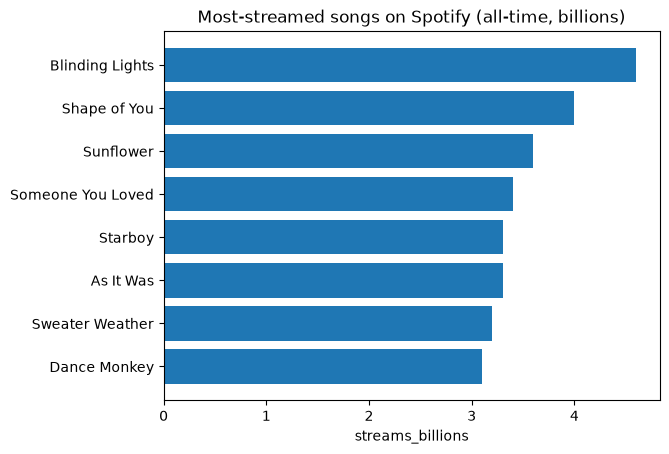

In [3]:
t = tracks.sort_values('streams_billions')  # barh reads bottom-up

fig, ax = plt.subplots()
ax.barh(t['track'], t['streams_billions'])
ax.set_title('Most-streamed songs on Spotify (all-time, billions)')
ax.set_xlabel('streams_billions')
plt.show()

### Line — user growth (raw)

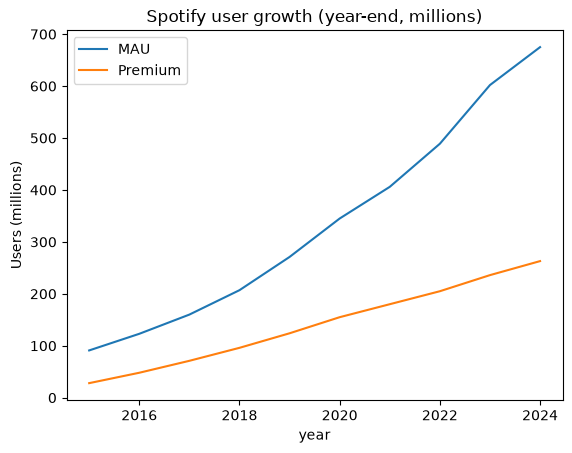

In [4]:
fig, ax = plt.subplots()
ax.plot(growth['year'], growth['MAU'], label='MAU')
ax.plot(growth['year'], growth['Premium'], label='Premium')
ax.set_title('Spotify user growth (year-end, millions)')
ax.set_xlabel('year')
ax.set_ylabel('Users (millions)')
ax.legend()
plt.show()

---
# 2 · After — spotviz

Same data, one function call each. Note what changed with **zero** extra
configuration: a dark identity, a single green accent on the mark that
matters, decluttered spines/grid, direct series labels instead of a legend,
value labels, and an honest zero baseline.

### Bar — highlight the #1 (after)

`highlight=` turns one bar green and mutes the rest, so the eye lands on the
point you're making. `sort='desc'` orders it; `label_values=True` prints the
numbers.

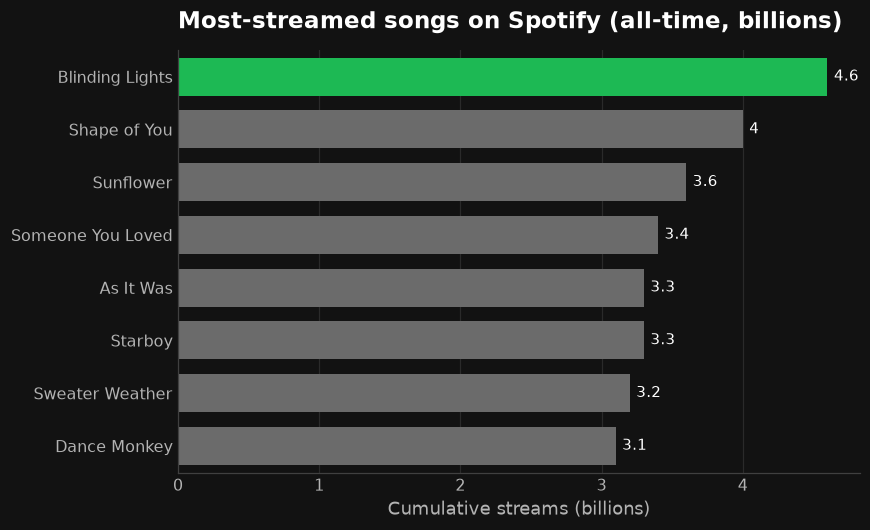

In [5]:
ax = sv.bar(
    tracks, x='track', y='streams_billions',
    sort='desc', highlight='Blinding Lights',
    orient='horizontal', label_values=True,
    title='Most-streamed songs on Spotify (all-time, billions)',
    xlabel='Cumulative streams (billions)', ylabel='',
)
plt.show()

### Line — direct labels, no legend (after)

Multiple series use the colorblind-checked categorical palette (green is
reserved for accent, so it's deliberately *not* one of these), and each line
is labeled at its end instead of in a legend box.

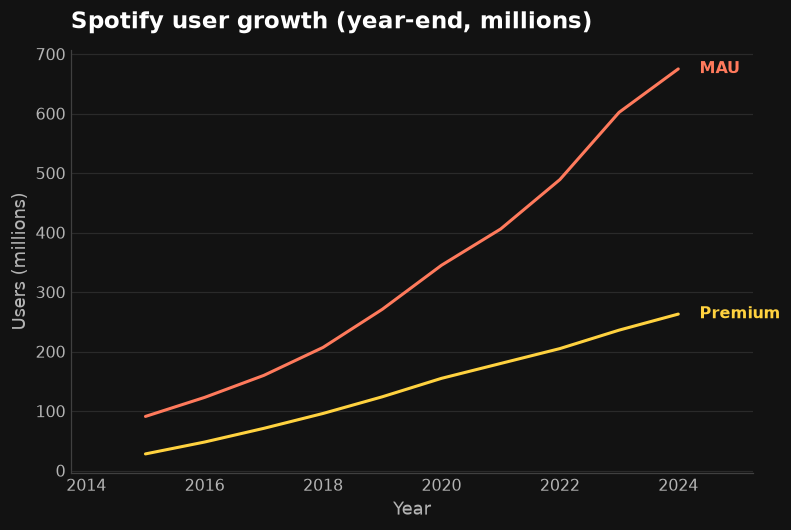

In [6]:
ax = sv.line(
    growth, x='year',
    title='Spotify user growth (year-end, millions)',
    xlabel='Year', ylabel='Users (millions)',
)
plt.show()

---
# 3 · One argument away

The same helpers switch mode or theme without touching the data or the
honesty rules.

### Presentation / report mode

`presentation=True` scales type and sizing for slides (16:9), keeping the
same identity.

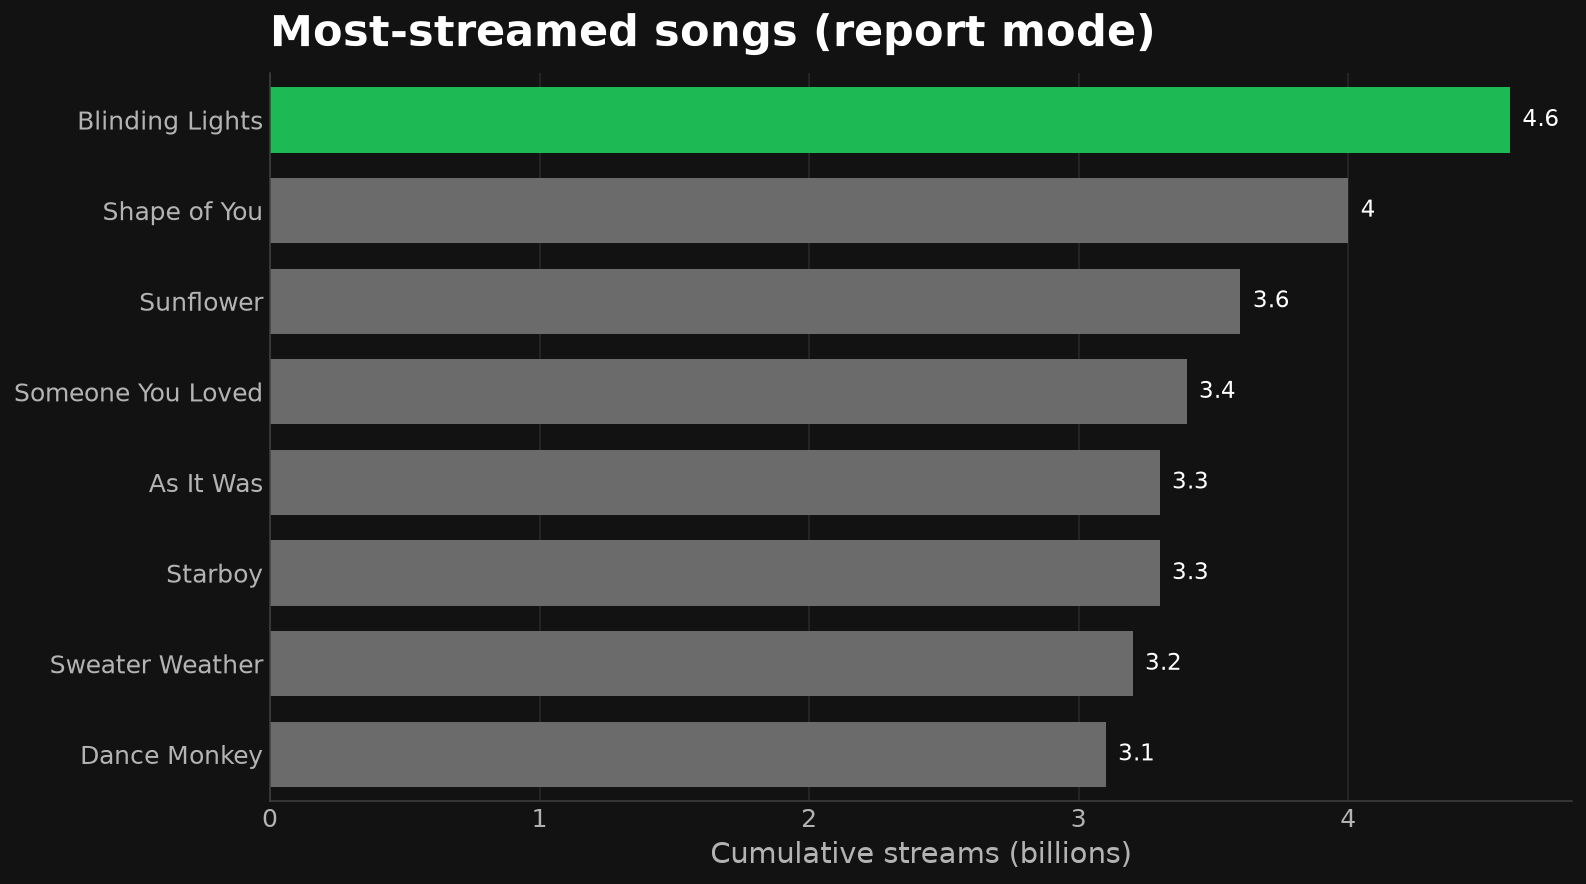

In [7]:
ax = sv.bar(
    tracks, x='track', y='streams_billions',
    sort='desc', highlight='Blinding Lights', orient='horizontal',
    label_values=True, presentation=True,
    title='Most-streamed songs (report mode)',
    xlabel='Cumulative streams (billions)', ylabel='',
)
plt.show()

### Light theme

`theme='light'` gives the print/journal variant — white ground, dark text,
same green accent.

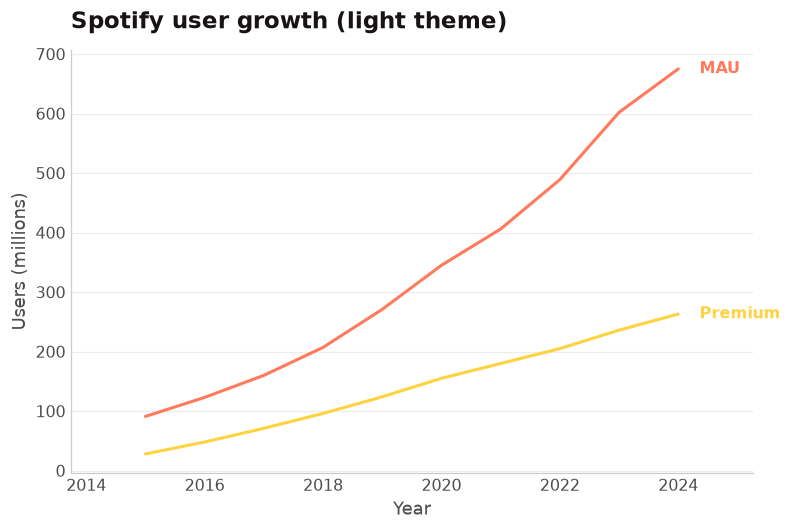

In [8]:
ax = sv.line(
    growth, x='year', theme='light',
    title='Spotify user growth (light theme)',
    xlabel='Year', ylabel='Users (millions)',
)
plt.show()

---
## Takeaways

| | Raw matplotlib | spotviz |
|---|---|---|
| Color | flat blue, no focus | dark identity, one green accent |
| Series | legend to decode | direct labels at line ends |
| Clutter | full box, all spines | decluttered, subtle grid |
| Values | read off the axis | labeled on the bars |
| Effort | several lines each | one function call |

Every helper returns a normal matplotlib `Axes`, so you can keep customizing
with plain matplotlib after the fact.